# Simple Multilayer Perceptron

In [ ]:
import pyarrow.parquet as pq
import matplotlib.pyplot as plt # To view image inline in the kernel
import pandas as pd
import numpy as np
from PIL import Image
import io

In [ ]:
# Read the parquet file into an Arrow Table
def read_parquet_file_to_df(filename, num_data):
    return pq.read_table('train.parquet').to_pandas().head(num_data)

train_set_size = 100
test_set_size = 20

train_df = read_parquet_file_to_df('train.parquet', train_set_size)
test_df = read_parquet_file_to_df('test.parquet', test_set_size)

## Visualization

In [ ]:
train_df.head(1) # The data is already stored as a PNG image

,image,label
0,{'bytes': b'\x89PNG\r\n\x1a\n\x00\x00\x00\rIHD...,5


(np.float64(-0.5), np.float64(27.5), np.float64(27.5), np.float64(-0.5))

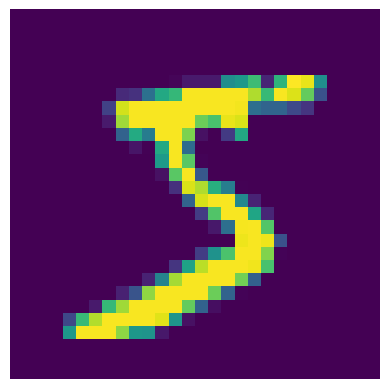

In [ ]:
# To view the image (the first one)
img = Image.open(io.BytesIO(train_df["image"].head(1).iloc[0]['bytes']))

plt.imshow(img)
plt.axis('off')

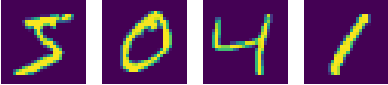

In [ ]:
# Showing the first 4 images
num_images = 4
images = []
width, height = 100, 100
for byte_image_dict in train_df["image"].head(num_images):
    images.append(Image.open(io.BytesIO(byte_image_dict['bytes'])))

# The code below shows the images vertically
# for image in images:
#     plt.figure(figsize=(width, height), dpi=1) # To ensure that each plot gets it's own figure (not overwrite the previous figure)
#     plt.imshow(image)
#     plt.axis('off')
#     plt.show()

# The code below shows the images horizontally (using subplots)
fig, axes = plt.subplots(1, 4, figsize=(width, height), dpi=5)
for i, ax in enumerate(axes.flatten()):
    ax.imshow(images[i])
    ax.axis('off')
    ax.set_aspect('equal')


In [ ]:
# Create a numpy array from bytes
byte_image_data = io.BytesIO(train_df["image"].head(1).iloc[0]['bytes']) # Encoded
image_data = Image.open(byte_image_data)

arr = np.array(image_data)

In [ ]:
# plt.imshow(arr, cmap='grey')
# # plt.colorbar()
# plt.show()

## CODE : Neural Network

Initialize the weights to **some values**. \
For this simple simulation, I am going to use 4 layers in total (input <-> HL<sub>1</sub> <-> HL<sub>2</sub> <-> output) with input dimension being 784 (28x28 image), 16 neurons for the HLs and 10 (0-9) outputs in total.

In [ ]:
# Dataset Preparation
def get_np_img_array(df):
    arr = []
    for data in df["image"]:
        arr.append(np.array(Image.open(io.BytesIO(data['bytes']))))
    return arr

train_images = get_np_img_array(train_df)
test_images = get_np_img_array(test_df)

train_labels = train_df["label"].to_numpy()
test_labels = test_df["label"].to_numpy()

In [ ]:
# There should a total of one weight matrix for each layer to layer
def populate_random(rows, cols):
    return np.random.rand(rows, cols) * 0.01

def init_weight_matrix(layers):
    wm = [None]
    for i in range(len(layers) - 1):
        wm.append(populate_random(layers[i], layers[i+1]))
    return wm

def init_bias_matrix(layers):
    bm = [None]
    for i in range(1, len(layers)):
        bm.append(
            np.zeros( (1, layers[i]) )
        )
    return bm

layers = [784, 16, 16, 10]
weight_matrix = init_weight_matrix(layers)
bias_matrix = init_bias_matrix(layers)

The first entry is "None" to keep the relevance with the formula:
$$a_j^{(L)} = \sigma \left( w_{jk}^{(L)} a_k^{(L-1)} + b_j^{(L)} \right)$$


#### Training
**Forward & Backward Propagation**

In [ ]:
def sigmoid(x):
    return 1 / (1 + np.exp(-x))

def one_hot_encode(num_classes, labels):
    l = []
    for label in labels:
        l.append(np.eye(num_classes)[label])
    return l

In [ ]:
layer2_neurons = np.random.rand(1, layers[1])
layer3_neurons = np.random.rand(1, layers[2])
layer4_neurons = np.random.rand(1, layers[3])

neurons = [None, layer2_neurons, layer3_neurons, layer4_neurons]
output_layer = len(neurons) - 1

start_idx = 0
batch_size = 20 # Process 20 images in a single forward pass
batch_no = 0
for batch in range(train_set_size // batch_size):
    end_idx = start_idx + batch_size

    for image in train_images[start_idx : end_idx]:
        neurons[0] = image.reshape(1, -1)
        for layer in range(1, len(bias_matrix)):
            neurons[layer] = sigmoid( (neurons[layer-1] @ weight_matrix[layer]) + bias_matrix[layer] )

    print(f"Completed --- Forward pass {batch_no}")
    print(neurons[output_layer])

    # cost += np.pow(np.subtract(neurons[output_layer], train_labels[start_idx : end_idx]), 2)
    # cost = cost/batch_size

    batch_no += 1
    start_idx = end_idx


16
Completed --- Forward pass 0
[[0.50999934 0.5092073  0.50870873 0.51270214 0.5114039  0.51120215
  0.51045106 0.51159784 0.50833507 0.51048572]]
Completed --- Forward pass 1
[[0.50999934 0.5092073  0.50870873 0.51270214 0.5114039  0.51120215
  0.51045106 0.51159784 0.50833507 0.51048572]]
Completed --- Forward pass 2
[[0.50999934 0.5092073  0.50870873 0.51270214 0.5114039  0.51120215
  0.51045106 0.51159784 0.50833507 0.51048572]]
Completed --- Forward pass 3
[[0.50999934 0.5092073  0.50870873 0.51270214 0.5114039  0.51120215
  0.51045106 0.51159784 0.50833507 0.51048572]]
Completed --- Forward pass 4
[[0.50999934 0.5092073  0.50870873 0.51270214 0.5114039  0.51120215
  0.51045106 0.51159784 0.50833507 0.51048572]]
